Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9586 - loss: 0.1358 - val_accuracy: 0.9845 - val_loss: 0.0530
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9864 - loss: 0.0432 - val_accuracy: 0.9878 - val_loss: 0.0439
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9910 - loss: 0.0292 - val_accuracy: 0.9890 - val_loss: 0.0415
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9903 - val_loss: 0.0355
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9950 - loss: 0.0158 - val_accuracy: 0.9898 - val_loss: 0.0397
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9928 - val_loss: 0.0340
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9964 - loss: 0.0102 - val_accuracy: 0.9910 - val_loss: 0.04

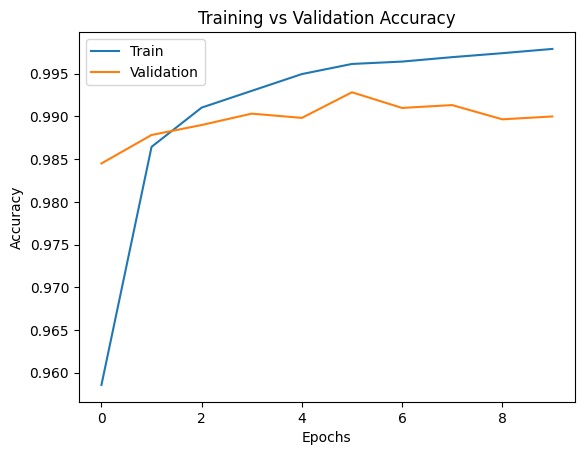

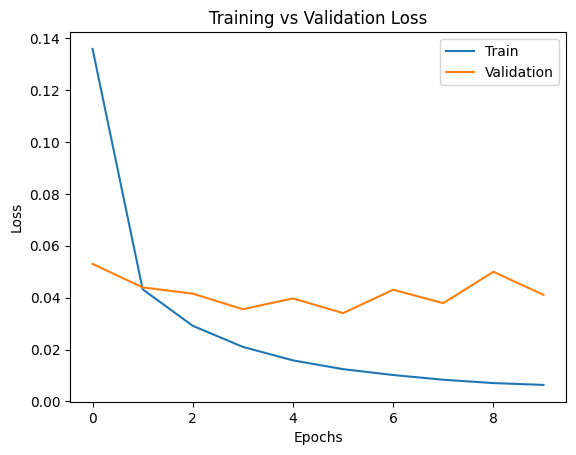

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape for CNN
# (28,28) → (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1) / 255.0

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Build CNN Model
model = Sequential([

    # 1st Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    # 2nd Convolution Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convert 2D → 1D
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Output Layer (0-9 digits)
    Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()